In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


In [2]:
np.random.seed(10)
n=200
age=np.random.randint(10,101,n)
bp=age*3 + np.random.normal(0,5,n)
df=pd.DataFrame({
    "Blood Pressure": bp,
    "Age": age
})
df.to_excel("BPvAge.xlsx", index=False)
print(df.isnull().sum())
print("\n")
df.isna()
print(df.head(10))
print("\n")
print(df.describe())

Blood Pressure    0
Age               0
dtype: int64


   Blood Pressure  Age
0       65.283583   19
1       78.339448   25
2      220.850267   74
3      108.352244   38
4      293.800187   99
5      118.569153   39
6       47.870820   18
7      247.891034   83
8       36.699632   10
9      150.146549   50


       Blood Pressure         Age
count      200.000000  200.000000
mean       166.024654   55.285000
std         83.325245   27.734995
min         24.967157   10.000000
25%         90.661271   30.250000
50%        157.679124   52.500000
75%        246.531052   82.250000
max        302.069923  100.000000


In [3]:
avg_bp=np.mean(bp)
avg_age=np.mean(age)
median_bp=np.median(bp)
median_age=np.median(age)   
mode_bp=stats.mode(bp)
mode_age=stats.mode(age)
std_bp=np.std(bp)
std_age=np.std(age)
var_bp=np.var(bp)
var_age=np.var(age)
print(f"Average Blood Pressure: {avg_bp}, Average Age: {avg_age}")
print(f"Median Blood Pressure: {median_bp}, Median Age: {median_age}")  
print(f"Mode Blood Pressure: {mode_bp}, Mode Age: {mode_age}")
print(f"Standard Deviation Blood Pressure: {std_bp}, Standard Deviation Age: {std_age}")
print(f"Variance Blood Pressure: {var_bp}, Variance Age: {var_age}")

Average Blood Pressure: 166.02465449455156, Average Age: 55.285
Median Blood Pressure: 157.67912434711195, Median Age: 52.5
Mode Blood Pressure: ModeResult(mode=np.float64(24.967157191019957), count=np.int64(1)), Mode Age: ModeResult(mode=np.int32(98), count=np.int64(8))
Standard Deviation Blood Pressure: 83.11667122478978, Standard Deviation Age: 27.665570209196847
Variance Blood Pressure: 6908.381035489798, Variance Age: 765.383775


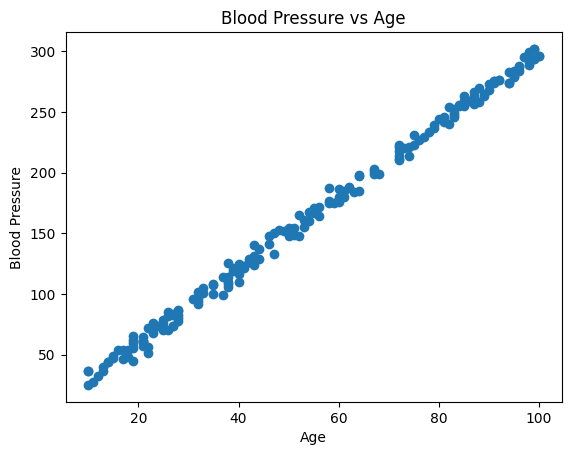

In [4]:
plt.scatter(age, bp)
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.title("Blood Pressure vs Age")
plt.show()

Slope: 2.999434489590306, Intercept: 0.2009187375514898


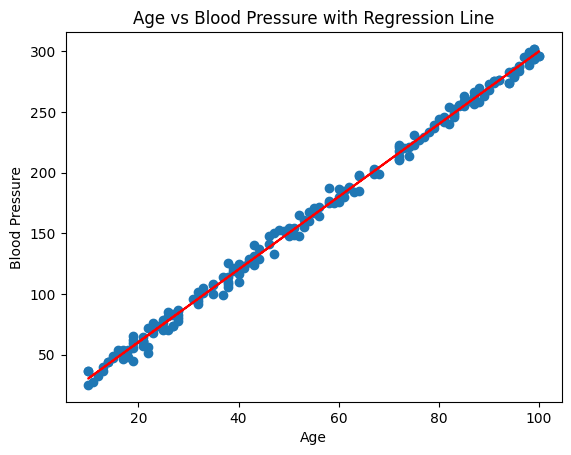

In [5]:
# Correct scatter plot (Age on X, BP on Y)
plt.scatter(age, bp)
plt.xlabel("Age")
plt.ylabel("Blood Pressure")

# Correct regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(age, bp)
print(f"Slope: {slope}, Intercept: {intercept}")
regression_line = slope *age + intercept
plt.plot(age, regression_line, color='red')

plt.title("Age vs Blood Pressure with Regression Line")
plt.show()



In [6]:
t_test = slope / std_err
dof = n - 2
tp_value = 2 * (1 - stats.t.cdf(abs(t_test), dof))
print(f"T-test statistic: {t_test}, P-value from T-test: {tp_value}")
print(f"Degrees of Freedom: {dof}")
alpha=0.05
if tp_value < alpha:
    print("Decision: Rejects H0")
    print("There is a siginificant relationship between Blood Pressure and Age and there is evidence of slope being non-zero")
else:
    print("Decision: Fails to Reject H0")
    print("There is no siginificant relationship between Blood Pressure and Age and there is no evidence of slope being non-zero")
    


T-test statistic: 246.03147361276936, P-value from T-test: 0.0
Degrees of Freedom: 198
Decision: Rejects H0
There is a siginificant relationship between Blood Pressure and Age and there is evidence of slope being non-zero


In [7]:
user_age = float(input("Enter your Age to predict Blood Pressure: "))
predicted_bp = slope * user_age + intercept
print(f"Predicted Blood Pressure for age {user_age} is: {predicted_bp}")


Predicted Blood Pressure for age 20.0 is: 60.18960852935761


In [8]:

bp_mean = np.mean(bp)
bp_std = np.std(bp, ddof=1)                          # sample standard deviation
n = len(bp)
t_crit = stats.t.ppf(0.975, df=n-1)
margin_error = t_crit * bp_std / np.sqrt(n)
lower_ci = bp_mean - margin_error
upper_ci = bp_mean + margin_error
print("\nMean Blood Pressure:", bp_mean)
print("95% Confidence Interval: (", lower_ci, ",", upper_ci, ")")





Mean Blood Pressure: 166.02465449455156
95% Confidence Interval: ( 154.40591689329452 , 177.6433920958086 )


In [9]:

bp_mean = np.mean(bp)
bp_std = np.std(bp, ddof=1)                          # sample standard deviation
n = len(bp)
t_crit = stats.t.ppf(0.95, df=n-1)
margin_error = t_crit * bp_std / np.sqrt(n)
lower_ci = bp_mean - margin_error
upper_ci = bp_mean + margin_error
print("\nMean Blood Pressure:", bp_mean)
print("90% Confidence Interval: (", lower_ci, ",", upper_ci, ")")


Mean Blood Pressure: 166.02465449455156
90% Confidence Interval: ( 156.28787450641968 , 175.76143448268343 )
